# Student Academic Performance Prediction Using KNN

**Course:** BMCS2203 Artificial Intelligence  
**Algorithm:** K-Nearest Neighbors (KNN)  
**Student Name:** Lim Jun Hao  
**Student ID:** 26WMR12877

This notebook develops a supervised multiclass classification model that predicts student performance as **Low**, **Medium**, or **High**.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

## 1. Dataset preparation

The dataset is loaded through a validated loader that checks the file, the required columns, and the target values before any modelling begins. The dataset is then inspected for its size, missing values, and duplicated records, and `Exam_Score` is converted into the target classes below.

| Exam score | Performance class |
|---|---|
| 64 or below | Low |
| 65 to 69 | Medium |
| 70 or above | High |

Dataset source: Student Performance Factors, Kaggle (https://www.kaggle.com/datasets/lainguyn123/student-performance-factors).

Loaded 'StudentPerformanceFactors.csv' successfully. All 20 required columns are present.

Dataset shape: (6607, 20)
Duplicated rows: 0
Exam_Score range: 55 to 101

Missing values:
Teacher_Quality             78
Parental_Education_Level    90
Distance_from_Home          67
dtype: int64

Performance class distribution:
Performance
Low       1452
Medium    3530
High      1625
Name: count, dtype: int64


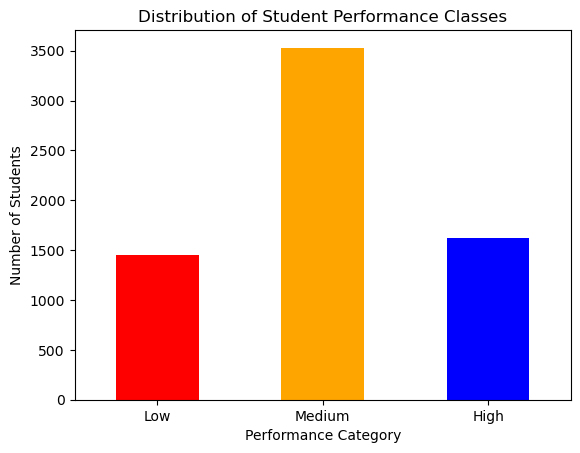

In [2]:
DATA_FILE = "StudentPerformanceFactors.csv"
TARGET_COLUMN = "Exam_Score"

REQUIRED_COLUMNS = [
    "Hours_Studied", "Attendance", "Parental_Involvement", "Access_to_Resources",
    "Extracurricular_Activities", "Sleep_Hours", "Previous_Scores", "Motivation_Level",
    "Internet_Access", "Tutoring_Sessions", "Family_Income", "Teacher_Quality",
    "School_Type", "Peer_Influence", "Physical_Activity", "Learning_Disabilities",
    "Parental_Education_Level", "Distance_from_Home", "Gender", "Exam_Score"
]


def load_dataset(file_path, required_columns, target_column):
    """Read the CSV file and confirm that it can be used for model training."""
    try:
        data = pd.read_csv(file_path)
    except FileNotFoundError:
        raise FileNotFoundError(
            f"'{file_path}' was not found. "
            "Place the CSV file in the same folder as this notebook."
        )
    except pd.errors.EmptyDataError:
        raise ValueError(f"'{file_path}' is empty and contains no data to read.")
    except pd.errors.ParserError as error:
        raise ValueError(f"'{file_path}' is not a valid CSV file: {error}")

    if data.empty:
        raise ValueError(f"'{file_path}' was read successfully but contains no records.")

    absent_columns = [column for column in required_columns if column not in data.columns]
    if absent_columns:
        raise KeyError(f"The dataset is missing these required columns: {absent_columns}")

    if not pd.api.types.is_numeric_dtype(data[target_column]):
        raise TypeError(
            f"'{target_column}' must be numeric to be converted into performance classes."
        )

    if data[target_column].isnull().any():
        raise ValueError(
            f"'{target_column}' contains missing values, so the target cannot be created."
        )

    return data


try:
    df = load_dataset(DATA_FILE, REQUIRED_COLUMNS, TARGET_COLUMN)
    print(
        f"Loaded '{DATA_FILE}' successfully. "
        f"All {len(REQUIRED_COLUMNS)} required columns are present."
    )
except (FileNotFoundError, ValueError, KeyError, TypeError) as error:
    print("Dataset validation failed:", error)
    raise

print()
print("Dataset shape:", df.shape)
print("Duplicated rows:", df.duplicated().sum())
print(f"{TARGET_COLUMN} range: {df[TARGET_COLUMN].min()} to {df[TARGET_COLUMN].max()}")
print()
print("Missing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

df["Performance"] = pd.cut(
    df["Exam_Score"],
    bins=[-np.inf, 64, 69, np.inf],
    labels=["Low", "Medium", "High"],
    ordered=True
)

class_order = ["Low", "Medium", "High"]
class_counts = df["Performance"].value_counts().reindex(class_order)

if df["Performance"].isnull().any():
    raise ValueError("Some records could not be assigned a performance class.")

empty_classes = class_counts[class_counts == 0].index.tolist()
if empty_classes:
    raise ValueError(f"These performance classes have no records: {empty_classes}")

print()
print("Performance class distribution:")
print(class_counts)

class_counts.plot(kind="bar", color=["red", "orange", "blue"])
plt.title("Distribution of Student Performance Classes")
plt.xlabel("Performance Category")
plt.ylabel("Number of Students")
plt.xticks(rotation=0)
plt.show()

## 2. Feature and target separation

`X` contains the student factors and `y` contains the target class. `Exam_Score` is removed from `X` because it was used to create `Performance`; keeping it would cause target leakage.

The data is split into 80% training and 20% testing data. Stratification maintains similar class proportions in both sets.

In [3]:
X = df.drop(columns=["Exam_Score", "Performance"])
y = df["Performance"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=np.number).columns.tolist()

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)
print("Numeric input features:", numeric_features)
print("Categorical input features:", categorical_features)
print()
print("Training class proportions:")
print(y_train.value_counts(normalize=True).sort_index())
print()
print("Testing class proportions:")
print(y_test.value_counts(normalize=True).sort_index())

Training data shape: (5285, 19)
Testing data shape: (1322, 19)
Numeric input features: ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity']
Categorical input features: ['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender']

Training class proportions:
Performance
Low       0.219678
Medium    0.534342
High      0.245979
Name: proportion, dtype: float64

Testing class proportions:
Performance
Low       0.220121
Medium    0.534039
High      0.245840
Name: proportion, dtype: float64


## 3. Preprocessing, feature selection, and KNN pipeline

Numerical features use median imputation and standardization. Categorical features use most-frequent imputation and one-hot encoding. `SelectKBest` retains the transformed features that have the strongest relationship with the target.

```text
Raw data -> preprocessing -> SelectKBest -> KNN
```

Every step is inside the Pipeline, so preprocessing and feature selection are fitted only on training data during cross-validation.

In [4]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

knn_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("selector", SelectKBest(score_func=f_classif)),
    ("knn", KNeighborsClassifier(algorithm="ball_tree"))
])

parameter_grid = {
    "selector__k": [4, 6, 8, 10, 12, 15, 20, "all"],
    "knn__n_neighbors": [9, 15, 21, 31, 41, 51],
    "knn__weights": ["uniform", "distance"],
    "knn__p": [1, 2]
}

cross_validation = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid_search = GridSearchCV(
    estimator=knn_pipeline,
    param_grid=parameter_grid,
    scoring={"accuracy": "accuracy", "macro_f1": "f1_macro"},
    refit="accuracy",
    cv=cross_validation,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

print("Parameter combinations:", 8 * 6 * 2 * 2)
print("Total cross-validation fits:", 8 * 6 * 2 * 2 * 5)

Parameter combinations: 192
Total cross-validation fits: 960


## 4. Model training and selection

GridSearchCV uses only the training set to select the number of features and the KNN hyperparameters. Accuracy is the primary selection metric, while Macro F1 is retained to evaluate class-balanced performance.

In [5]:
grid_search.fit(X_train, y_train)

best_index = grid_search.best_index_
best_cv_accuracy = grid_search.cv_results_["mean_test_accuracy"][best_index]
best_cv_macro_f1 = grid_search.cv_results_["mean_test_macro_f1"][best_index]
best_knn_model = grid_search.best_estimator_

all_transformed_features = best_knn_model[
    "preprocessor"
].get_feature_names_out()
selected_mask = best_knn_model["selector"].get_support()
selected_scores = best_knn_model["selector"].scores_[selected_mask]

selected_features = pd.DataFrame({
    "Selected Feature": all_transformed_features[selected_mask],
    "F Score": selected_scores
}).sort_values("F Score", ascending=False).reset_index(drop=True)

print("Best KNN parameters:")
print(grid_search.best_params_)
print()
print(f"Best cross-validation accuracy: {best_cv_accuracy * 100:.2f}%")
print(f"Cross-validation macro F1: {best_cv_macro_f1 * 100:.2f}%")
print()
print("Selected transformed input features:")
display(selected_features)

Fitting 5 folds for each of 192 candidates, totalling 960 fits
Best KNN parameters:
{'knn__n_neighbors': 15, 'knn__p': 2, 'knn__weights': 'distance', 'selector__k': 12}

Best cross-validation accuracy: 82.27%
Cross-validation macro F1: 80.76%

Selected transformed input features:


,Selected Feature,F Score
0,numeric__Attendance,1572.355181
1,numeric__Hours_Studied,677.725167
2,numeric__Previous_Scores,91.482834
3,categorical__Access_to_Resources_High,68.076287
4,numeric__Tutoring_Sessions,57.473237
5,categorical__Parental_Involvement_High,55.421475
6,categorical__Parental_Involvement_Low,45.177932
7,categorical__Access_to_Resources_Low,41.936844
8,categorical__Learning_Disabilities_Yes,30.561858
9,categorical__Learning_Disabilities_No,30.561858


,Selected Feature,F Score
0,numeric__Attendance,1572.355181
1,numeric__Hours_Studied,677.725167
2,numeric__Previous_Scores,91.482834
3,categorical__Access_to_Resources_High,68.076287
4,numeric__Tutoring_Sessions,57.473237
5,categorical__Parental_Involvement_High,55.421475
6,categorical__Parental_Involvement_Low,45.177932
7,categorical__Access_to_Resources_Low,41.936844
8,categorical__Learning_Disabilities_Yes,30.561858
9,categorical__Learning_Disabilities_No,30.561858


### 4.1 Validation curve

The cross-validation results show how accuracy changes with the number of neighbours while the other selected hyperparameters are held constant. The shaded band is one standard deviation across the five folds.

The training accuracy stays at 100% for every value of k. This is expected for `weights="distance"`: a training point is its own nearest neighbour at a distance of zero, so it receives an infinite weight and is always predicted correctly. Only the cross-validation curve is informative here, and it peaks at the selected value of k before slowly declining as larger neighbourhoods begin to blur the class boundaries.

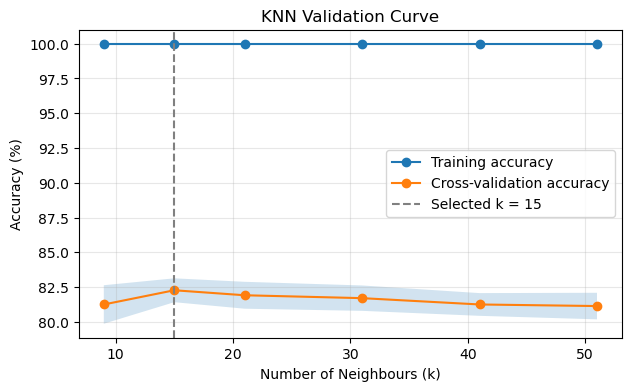

,Neighbours (k),Training Accuracy (%),Cross-Validation Accuracy (%)
0,9,100.0,81.25
1,15,100.0,82.27
2,21,100.0,81.91
3,31,100.0,81.70
4,41,100.0,81.25
5,51,100.0,81.14


In [6]:
cv_results = pd.DataFrame(grid_search.cv_results_)
best_parameters = grid_search.best_params_

curve = cv_results[
    (cv_results["param_knn__weights"] == best_parameters["knn__weights"])
    & (cv_results["param_knn__p"] == best_parameters["knn__p"])
    & (cv_results["param_selector__k"] == best_parameters["selector__k"])
].sort_values("param_knn__n_neighbors")

neighbour_values = curve["param_knn__n_neighbors"].astype(int).to_numpy()
training_accuracy = curve["mean_train_accuracy"].to_numpy()
validation_accuracy = curve["mean_test_accuracy"].to_numpy()
validation_deviation = curve["std_test_accuracy"].to_numpy()

plt.figure(figsize=(7, 4))
plt.plot(neighbour_values, training_accuracy * 100, marker="o", label="Training accuracy")
plt.plot(neighbour_values, validation_accuracy * 100, marker="o", label="Cross-validation accuracy")
plt.fill_between(
    neighbour_values,
    (validation_accuracy - validation_deviation) * 100,
    (validation_accuracy + validation_deviation) * 100,
    alpha=0.20
)
plt.axvline(
    best_parameters["knn__n_neighbors"],
    linestyle="--",
    color="grey",
    label=f"Selected k = {best_parameters['knn__n_neighbors']}"
)
plt.title("KNN Validation Curve")
plt.xlabel("Number of Neighbours (k)")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(alpha=0.30)
plt.show()

curve_table = pd.DataFrame({
    "Neighbours (k)": neighbour_values,
    "Training Accuracy (%)": training_accuracy * 100,
    "Cross-Validation Accuracy (%)": validation_accuracy * 100
})
display(curve_table.round(2))

## 5. Final evaluation

The selected model is evaluated once on the held-out test set. A majority-class DummyClassifier is also used as a baseline reference.

In [7]:
y_pred = best_knn_model.predict(X_test)

baseline_model = DummyClassifier(strategy="most_frequent")
baseline_model.fit(X_train, y_train)
baseline_pred = baseline_model.predict(X_test)

baseline_accuracy = accuracy_score(y_test, baseline_pred)
baseline_balanced_accuracy = balanced_accuracy_score(y_test, baseline_pred)
test_accuracy = accuracy_score(y_test, y_pred)
test_balanced_accuracy = balanced_accuracy_score(y_test, y_pred)

macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
    y_test,
    y_pred,
    labels=class_order,
    average="macro",
    zero_division=0
)

weighted_precision, weighted_recall, weighted_f1, _ = precision_recall_fscore_support(
    y_test,
    y_pred,
    labels=class_order,
    average="weighted",
    zero_division=0
)

knn_confusion_matrix = confusion_matrix(
    y_test,
    y_pred,
    labels=class_order
)
confusion_table = pd.DataFrame(
    knn_confusion_matrix,
    index=class_order,
    columns=class_order
)

print("=" * 60)
print("KNN Classification")
print("=" * 60)
print()
print("Best Hyperparameters")
print(grid_search.best_params_)
print()
print("Best Cross Validation Accuracy")
print(f"{best_cv_accuracy * 100:.2f}%")
print()
print("Cross Validation Macro F1")
print(f"{best_cv_macro_f1 * 100:.2f}%")
print()
print("Test Accuracy")
print(f"{test_accuracy * 100:.2f}%")
print()
print("Balanced Accuracy")
print(f"{test_balanced_accuracy * 100:.2f}%")
print()
print("Classification Report")
print(classification_report(
    y_test,
    y_pred,
    labels=class_order,
    target_names=class_order,
    digits=4,
    zero_division=0
))
print("Macro Average")
print(f"Precision : {macro_precision * 100:.2f}%")
print(f"Recall    : {macro_recall * 100:.2f}%")
print(f"F1 Score  : {macro_f1 * 100:.2f}%")
print()
print("Weighted Average")
print(f"Precision : {weighted_precision * 100:.2f}%")
print(f"Recall    : {weighted_recall * 100:.2f}%")
print(f"F1 Score  : {weighted_f1 * 100:.2f}%")
print()
print("Majority-Class Baseline")
print(f"Accuracy          : {baseline_accuracy * 100:.2f}%")
print(f"Balanced Accuracy : {baseline_balanced_accuracy * 100:.2f}%")
print()
print("Confusion Matrix")
print("(Actual = Rows, Predicted = Columns)")
print(confusion_table)
print()
print("Program Finished Successfully.")

KNN Classification

Best Hyperparameters
{'knn__n_neighbors': 15, 'knn__p': 2, 'knn__weights': 'distance', 'selector__k': 12}

Best Cross Validation Accuracy
82.27%

Cross Validation Macro F1
80.76%

Test Accuracy
82.30%

Balanced Accuracy
77.89%

Classification Report
              precision    recall  f1-score   support

         Low     0.8986    0.6701    0.7677       291
      Medium     0.7862    0.9221    0.8488       706
        High     0.8736    0.7446    0.8040       325

    accuracy                         0.8230      1322
   macro avg     0.8528    0.7789    0.8068      1322
weighted avg     0.8325    0.8230    0.8199      1322

Macro Average
Precision : 85.28%
Recall    : 77.89%
F1 Score  : 80.68%

Weighted Average
Precision : 83.25%
Recall    : 82.30%
F1 Score  : 81.99%

Majority-Class Baseline
Accuracy          : 53.40%
Balanced Accuracy : 33.33%

Confusion Matrix
(Actual = Rows, Predicted = Columns)
        Low  Medium  High
Low     195      96     0
Medium   20     6

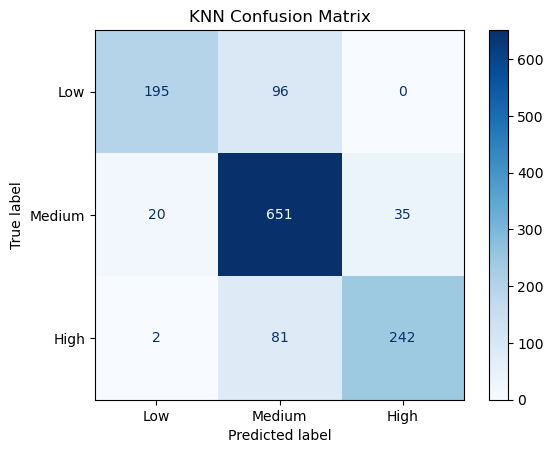

In [8]:
ConfusionMatrixDisplay(
    confusion_matrix=knn_confusion_matrix,
    display_labels=class_order
).plot(cmap="Blues", values_format="d")

plt.title("KNN Confusion Matrix")
plt.grid(False)
plt.show()

## 6. Prediction for a new student

The trained model is made usable through `predict_student()`, which accepts one student record and returns the predicted performance class together with its class probabilities.

Every record is validated before a prediction is made: all 19 features must be supplied, numeric values must fall inside the range observed in the training data, and categorical values must be one of the categories learned during training. Records that break these rules are rejected with a message that names the specific problem, instead of returning a misleading prediction.

In [9]:
feature_columns = X_train.columns.tolist()

numeric_ranges = {
    column: (X_train[column].min(), X_train[column].max())
    for column in numeric_features
}
allowed_categories = {
    column: sorted(X_train[column].dropna().unique().tolist())
    for column in categorical_features
}


def validate_student_record(record):
    """Check one student record against the rules learned from the training data."""
    if not isinstance(record, dict):
        raise TypeError("A student record must be a dictionary of feature names and values.")

    problems = []

    missing_fields = [column for column in feature_columns if column not in record]
    if missing_fields:
        problems.append(f"Missing required features: {missing_fields}")

    unknown_fields = [column for column in record if column not in feature_columns]
    if unknown_fields:
        problems.append(f"Unknown features that the model was not trained on: {unknown_fields}")

    for column, (lowest, highest) in numeric_ranges.items():
        if column not in record:
            continue
        value = record[column]
        if isinstance(value, bool) or not isinstance(value, (int, float, np.integer, np.floating)):
            problems.append(f"'{column}' must be a number but received {value!r}.")
        elif pd.isnull(value):
            problems.append(f"'{column}' cannot be empty.")
        elif not lowest <= value <= highest:
            problems.append(
                f"'{column}' is {value}, which is outside the trained range {lowest} to {highest}."
            )

    for column, categories in allowed_categories.items():
        if column not in record:
            continue
        if record[column] not in categories:
            problems.append(f"'{column}' is {record[column]!r}, but must be one of {categories}.")

    if problems:
        raise ValueError("Invalid student record:\n- " + "\n- ".join(problems))


def predict_student(record, model=best_knn_model):
    """Validate one student record and predict the performance class for it."""
    validate_student_record(record)

    student_frame = pd.DataFrame([record])[feature_columns]
    predicted_class = model.predict(student_frame)[0]
    predicted_probabilities = model.predict_proba(student_frame)[0]

    probabilities = {
        str(class_name): float(probability)
        for class_name, probability in zip(model.classes_, predicted_probabilities)
    }
    return str(predicted_class), probabilities


def show_prediction(title, record):
    """Print the prediction for one student, or the reason the record was rejected."""
    print(title)
    print("-" * len(title))
    try:
        predicted_class, probabilities = predict_student(record)
    except (TypeError, ValueError) as error:
        print(error)
    else:
        print(f"Predicted performance: {predicted_class}")
        for class_name in class_order:
            print(f"  {class_name:<7}: {probabilities[class_name] * 100:5.2f}%")
    print()


strong_student = {
    "Hours_Studied": 30, "Attendance": 95, "Sleep_Hours": 7, "Previous_Scores": 85,
    "Tutoring_Sessions": 3, "Physical_Activity": 3,
    "Parental_Involvement": "High", "Access_to_Resources": "High",
    "Extracurricular_Activities": "Yes", "Motivation_Level": "High",
    "Internet_Access": "Yes", "Family_Income": "Medium", "Teacher_Quality": "High",
    "School_Type": "Public", "Peer_Influence": "Positive", "Learning_Disabilities": "No",
    "Parental_Education_Level": "Postgraduate", "Distance_from_Home": "Near", "Gender": "Female"
}

weak_student = {
    "Hours_Studied": 8, "Attendance": 62, "Sleep_Hours": 5, "Previous_Scores": 55,
    "Tutoring_Sessions": 0, "Physical_Activity": 1,
    "Parental_Involvement": "Low", "Access_to_Resources": "Low",
    "Extracurricular_Activities": "No", "Motivation_Level": "Low",
    "Internet_Access": "No", "Family_Income": "Low", "Teacher_Quality": "Low",
    "School_Type": "Public", "Peer_Influence": "Negative", "Learning_Disabilities": "Yes",
    "Parental_Education_Level": "High School", "Distance_from_Home": "Far", "Gender": "Male"
}

invalid_student = dict(strong_student)
invalid_student["Attendance"] = 150
invalid_student["Motivation_Level"] = "Very High"

incomplete_student = dict(strong_student)
del incomplete_student["Hours_Studied"]

show_prediction("Student A: strong study profile", strong_student)
show_prediction("Student B: weak study profile", weak_student)
show_prediction("Student C: invalid values (rejected)", invalid_student)
show_prediction("Student D: missing feature (rejected)", incomplete_student)

Student A: strong study profile
-------------------------------
Predicted performance: High
  Low    :  0.00%
  Medium :  0.00%
  High   : 100.00%

Student B: weak study profile
-----------------------------
Predicted performance: Low
  Low    : 100.00%
  Medium :  0.00%
  High   :  0.00%

Student C: invalid values (rejected)
------------------------------------
Invalid student record:
- 'Attendance' is 150, which is outside the trained range 60 to 100.
- 'Motivation_Level' is 'Very High', but must be one of ['High', 'Low', 'Medium'].

Student D: missing feature (rejected)
-------------------------------------
Invalid student record:
- Missing required features: ['Hours_Studied']



Predicted performance: Low
  Low    : 100.00%
  Medium :  0.00%
  High   :  0.00%

Student C: invalid values (rejected)
------------------------------------
Invalid student record:
- 'Attendance' is 150, which is outside the trained range 60 to 100.
- 'Motivation_Level' is 'Very High', but must be one of ['High', 'Low', 'Medium'].

Student D: missing feature (rejected)
-------------------------------------
Invalid student record:
- Missing required features: ['Hours_Studied']



## 7. Result interpretation

The summary below is generated from the stored results, so the reported values always match the most recent run of this notebook.

In [10]:
evaluation_report = classification_report(
    y_test,
    y_pred,
    labels=class_order,
    target_names=class_order,
    output_dict=True,
    zero_division=0
)

class_recalls = {class_name: evaluation_report[class_name]["recall"] for class_name in class_order}
strongest_class = max(class_recalls, key=class_recalls.get)
weakest_class = min(class_recalls, key=class_recalls.get)

misclassifications = [
    (class_order[actual], class_order[predicted], knn_confusion_matrix[actual][predicted])
    for actual in range(len(class_order))
    for predicted in range(len(class_order))
    if actual != predicted and knn_confusion_matrix[actual][predicted] > 0
]
misclassifications.sort(key=lambda error: error[2], reverse=True)

selected_count = len(selected_features)
total_count = len(all_transformed_features)
distance_name = "Manhattan" if best_parameters["knn__p"] == 1 else "Euclidean"

print("Result Interpretation")
print("=" * 60)
print()
print(
    f"The optimised KNN model achieved {test_accuracy * 100:.2f}% test accuracy, which is "
    f"{(test_accuracy - baseline_accuracy) * 100:.2f} percentage points above the majority-class "
    f"baseline of {baseline_accuracy * 100:.2f}%."
)
print(
    f"Its test macro F1 was {macro_f1 * 100:.2f}%, while the cross-validation accuracy and macro F1 "
    f"were {best_cv_accuracy * 100:.2f}% and {best_cv_macro_f1 * 100:.2f}%."
)
print(
    f"The cross-validation and test accuracy differ by only "
    f"{abs(best_cv_accuracy - test_accuracy) * 100:.2f} percentage points, which indicates "
    f"consistent performance on unseen data."
)
print()
print(
    f"The {strongest_class} class had the strongest recall at "
    f"{class_recalls[strongest_class] * 100:.2f}%, while the {weakest_class} class had the weakest "
    f"recall at {class_recalls[weakest_class] * 100:.2f}%."
)
print("The most common errors were:")
for actual_class, predicted_class, count in misclassifications[:2]:
    print(f"  {count} {actual_class} students predicted as {predicted_class}")
print()
print(
    f"Feature selection kept {selected_count} of the {total_count} transformed features, so the "
    f"weaker features were removed from the KNN distance calculation."
)
print(
    f"The selected hyperparameters were k = {best_parameters['knn__n_neighbors']}, "
    f"weights = '{best_parameters['knn__weights']}', and p = {best_parameters['knn__p']} "
    f"({distance_name} distance)."
)

Result Interpretation

The optimised KNN model achieved 82.30% test accuracy, which is 28.90 percentage points above the majority-class baseline of 53.40%.
Its test macro F1 was 80.68%, while the cross-validation accuracy and macro F1 were 82.27% and 80.76%.
The cross-validation and test accuracy differ by only 0.03 percentage points, which indicates consistent performance on unseen data.

The Medium class had the strongest recall at 92.21%, while the Low class had the weakest recall at 67.01%.
The most common errors were:
  96 Low students predicted as Medium
  81 High students predicted as Medium

Feature selection kept 12 of the 40 transformed features, so the weaker features were removed from the KNN distance calculation.
The selected hyperparameters were k = 15, weights = 'distance', and p = 2 (Euclidean distance).
